This notebook contains code for generating images related to quantum neural networks used in the article regarding Synthetic datasets.

<a id="0"></a>
1. [Visualizing a Strongly Entangling Layer in PennyLane](#1)
2. [Umlaut dataset Current and Power](#2)
3. [Umlaut loss function](#3)

Each folder contains a single training configuration. The naming convention follows 'exp_R_L', where R represents the number of qubits and L indicates the number of layers. Inside each folder, there is a file named df_metric.csv, which stores training results (learning capability, std). The training results from a specific experiment are loaded.

In [1]:
import pandas as pd

# Load the user's CSV file to check its contents
file_path = 'exp_1_12/df_metrics.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first few rows to understand the structure of the data
df.head()

,Encoding,Normalization,R,L,N,s,trainable_block_layers,ansatz,max_iter,step_size,Learning capability,Standard deviation
0,binary,L2 normalization,2,6,1,"[0, 1]",5,sequential,3000,0.05,0.002455,0.000694
1,binary,Min-Max normalization,2,6,1,"[0, 1]",5,sequential,3000,0.05,0.009239,0.003170
2,hamming,L2 normalization,2,6,1,"[0, 1]",5,sequential,3000,0.05,0.000004,0.000028
3,hamming,Min-Max normalization,2,6,1,"[0, 1]",5,sequential,3000,0.05,0.000015,0.000018
4,hamming,Half range normalization,2,6,1,"[0, 1]",5,sequential,3000,0.05,0.004352,0.006273


All normalization on the same plot

In [5]:
from experiments.plotting import plot_learning_capabilities
import experiments.constants as const_exp
from qnn import QNN

model = QNN(R=2,
            L=6,
            N=1,
            ansatz=const_exp.MODEL_SEQUENTIAL,
            encoding=const_exp.EXPONENTIAL,
            trainable_block_layers=5,
            save_weights=True,
            save_losses=True,
            max_iter=3000,
            step_size=0.05,
            verbose=True,
            s=[0,1])


plot_learning_capabilities(df, [const_exp.L2_NORMALIZATION, const_exp.MIN_MAX_NORMALIZATION,const_exp.HALF_RANGE_NORMALIZATION], [const_exp.HAMMING, const_exp.EXPONENTIAL,const_exp.BINARY,const_exp.TERNARY,const_exp.GOLOMB, const_exp.TURNPIKE], model, save_plot=True, save_model_params=False, filename=f'test\\1_12')

C:\Users\marty\AppData\Local\Temp\ipykernel_8940\2427485951.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="Encoding", y="Learning capability", hue="Normalization", ci="sd")


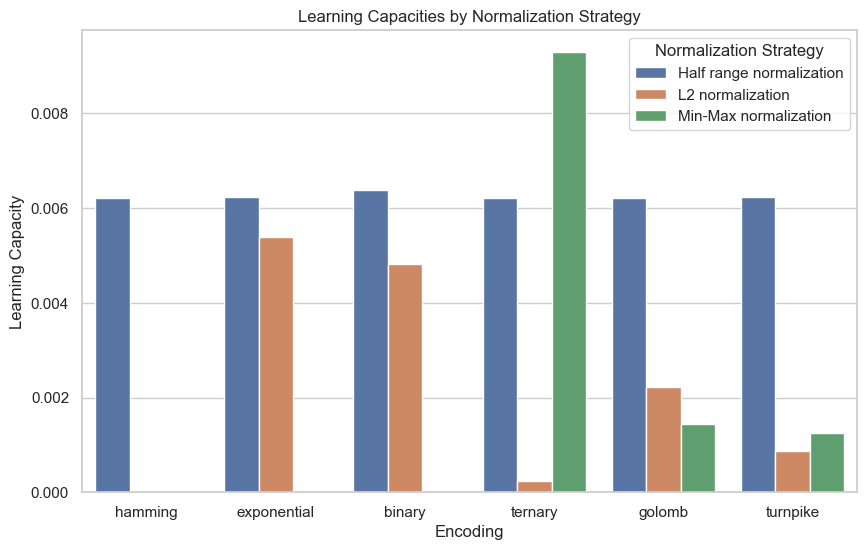

In [11]:
import matplotlib.pyplot as plt
# Set up the plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Encoding", y="Learning capability", hue="Normalization", ci="sd")

# Customize plot labels and title
plt.title("Learning Capacities by Normalization Strategy")
plt.xlabel("Encoding")
plt.ylabel("Learning Capacity")
plt.legend(title="Normalization Strategy")

# Save and show the plot
plt.savefig("learning_capacities_plot.png")
plt.show()

C:\Users\marty\AppData\Local\Temp\ipykernel_8940\1926041452.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Encoding', y='Learning capability', hue='Normalization', data=df,


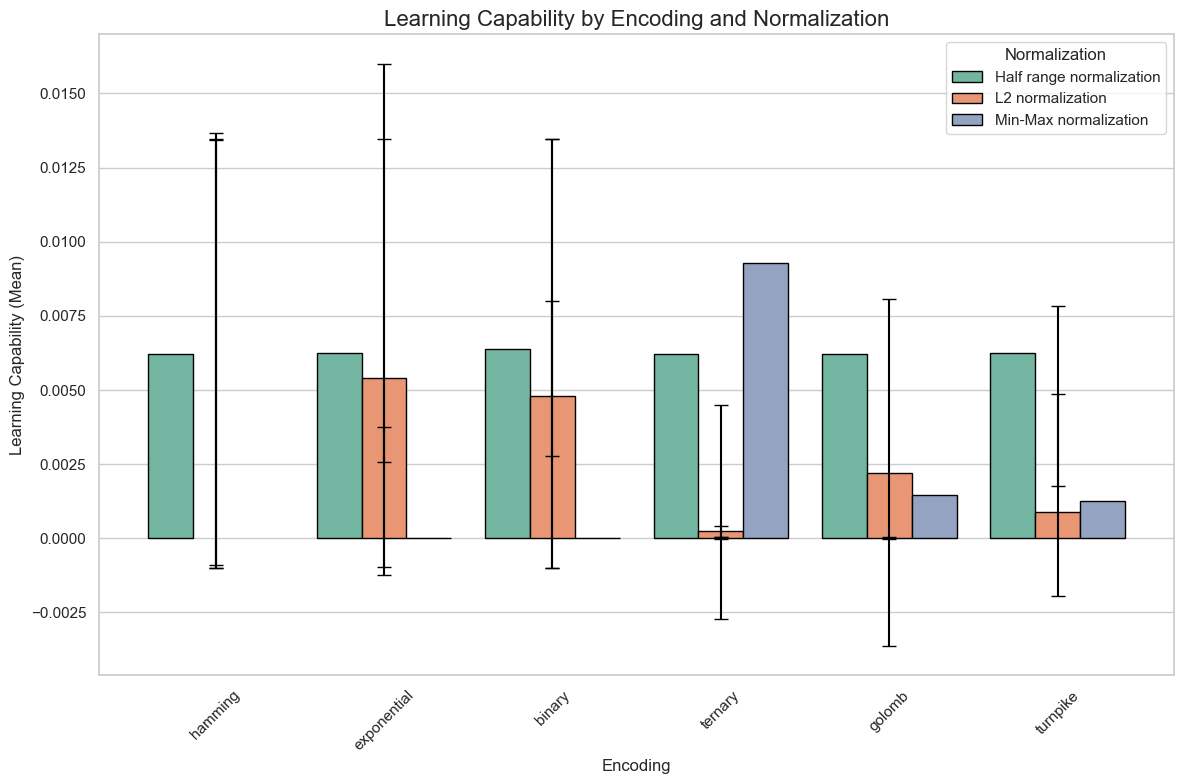

In [5]:
# Create a more visually appealing plot using grouped bar plots for better comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 8))

# Set seaborn style
sns.set(style="whitegrid")

# Plot grouped barplot with error bars
sns.barplot(x='Encoding', y='Learning capability', hue='Normalization', data=df,
            ci=None, palette='Set2', edgecolor='black', capsize=.2, errwidth=1)

# Add error bars manually
for i, row in df.iterrows():
    plt.errorbar(x=i % len(df['Encoding'].unique()),
                 y=row['Learning capability'],
                 yerr=row['Standard deviation'],
                 fmt='none', c='black', capsize=5)

# Customize the labels and title
plt.title('Learning Capability by Encoding and Normalization', fontsize=16)
plt.ylabel('Learning Capability (Mean)', fontsize=12)
plt.xlabel('Encoding', fontsize=12)
plt.xticks(rotation=45)

# Add a legend
plt.legend(title='Normalization')

# Show the plot
plt.tight_layout()
plt.show()


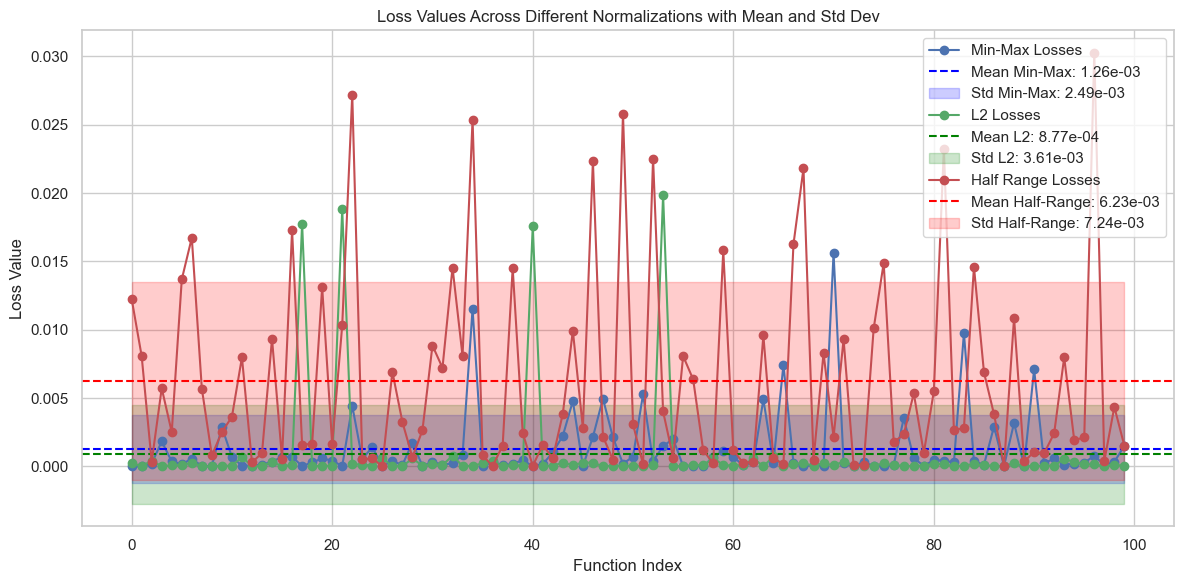

In [56]:
# Plotting loss values for all three normalization strategies in a single plot

import numpy as np
import matplotlib.pyplot as plt


# Function to create a plot for the loss values, mean, and std
def plot_combined_losses(minmax_losses, l2_losses, half_range_losses):
    x = np.arange(len(minmax_losses))

    # Calculate means and stds
    minmax_mean = np.mean(minmax_losses)
    minmax_std = np.std(minmax_losses)

    l2_mean = np.mean(l2_losses)
    l2_std = np.std(l2_losses)

    half_range_mean = np.mean(half_range_losses)
    half_range_std = np.std(half_range_losses)

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot Min-Max normalization
    ax.plot(x, minmax_losses, 'bo-', label='Min-Max Losses')
    ax.axhline(minmax_mean, color='blue', linestyle='--', label=f'Mean Min-Max: {minmax_mean:.2e}')
    ax.fill_between(x, minmax_mean - minmax_std, minmax_mean + minmax_std, color='blue', alpha=0.2, label=f'Std Min-Max: {minmax_std:.2e}')

    # Plot L2 normalization
    ax.plot(x, l2_losses, 'go-', label='L2 Losses')
    ax.axhline(l2_mean, color='green', linestyle='--', label=f'Mean L2: {l2_mean:.2e}')
    ax.fill_between(x, l2_mean - l2_std, l2_mean + l2_std, color='green', alpha=0.2, label=f'Std L2: {l2_std:.2e}')

    # Plot Half-Range normalization
    ax.plot(x, half_range_losses, 'ro-', label='Half Range Losses')
    ax.axhline(half_range_mean, color='red', linestyle='--', label=f'Mean Half-Range: {half_range_mean:.2e}')
    ax.fill_between(x, half_range_mean - half_range_std, half_range_mean + half_range_std, color='red', alpha=0.2, label=f'Std Half-Range: {half_range_std:.2e}')

    # Labels and Title
    ax.set_xlabel('Function Index')
    ax.set_ylabel('Loss Value')
    ax.set_title('Loss Values Across Different Normalizations with Mean and Std Dev')

    # Show legend
    ax.legend()

    # Show plot
    plt.tight_layout()
    plt.show()

# Call the function to create the combined plot
plot_combined_losses(MIN_MAX_NORMALIZATION_test_losses_array, L2_NORMALIZATION_test_losses_array, HALF_RANGE_NORMALIZATION_test_losses_array)


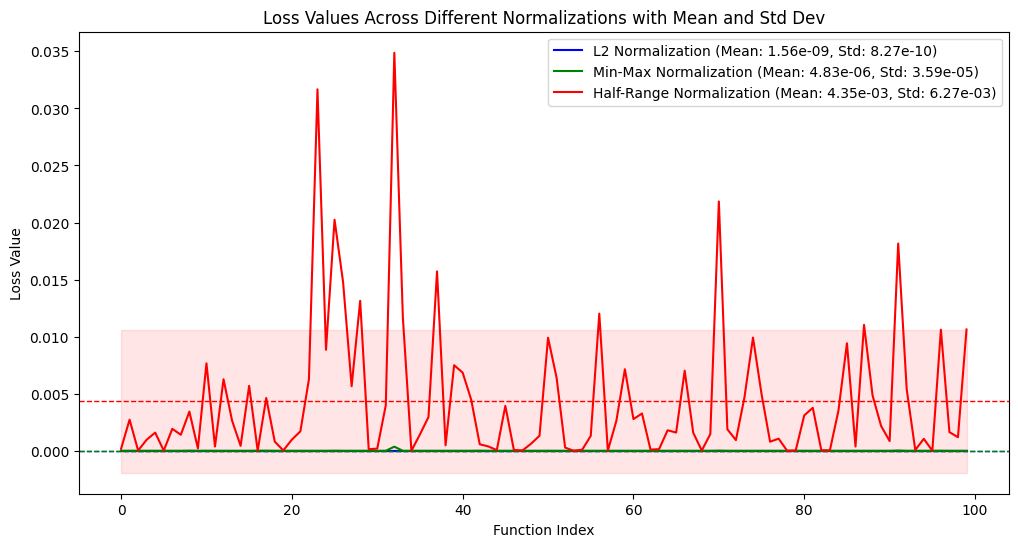

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_normalizations(min_max_losses, l2_losses, half_range_losses):
    # Create a figure and axis

    # Calculate means and stds
    min_max_mean = np.mean(min_max_losses)
    min_max_std = np.std(min_max_losses)

    l2_mean = np.mean(l2_losses)
    l2_std = np.std(l2_losses)

    half_range_mean = np.mean(half_range_losses)
    half_range_std = np.std(half_range_losses)

    plt.figure(figsize=(12, 6))

    # Plot L2 normalization losses
    x_vals = np.arange(len(l2_losses))
    plt.plot(x_vals, l2_losses, '-', color='blue', label=f'L2 Normalization (Mean: {l2_mean:.2e}, Std: {l2_std:.2e})')
    plt.axhline(y=l2_mean, color='blue', linestyle='--', linewidth=1)
    plt.fill_between(x_vals, l2_mean - l2_std, l2_mean + l2_std, color='blue', alpha=0.1)

    # Plot Min-Max normalization losses
    plt.plot(x_vals, min_max_losses, '-', color='green', label=f'Min-Max Normalization (Mean: {min_max_mean:.2e}, Std: {min_max_std:.2e})')
    plt.axhline(y=min_max_mean, color='green', linestyle='--', linewidth=1)
    plt.fill_between(x_vals, min_max_mean - min_max_std, min_max_mean + min_max_std, color='green', alpha=0.1)

    # Plot Half-Range normalization losses
    plt.plot(x_vals, half_range_losses, '-', color='red', label=f'Half-Range Normalization (Mean: {half_range_mean:.2e}, Std: {half_range_std:.2e})')
    plt.axhline(y=half_range_mean, color='red', linestyle='--', linewidth=1)
    plt.fill_between(x_vals, half_range_mean - half_range_std, half_range_mean + half_range_std, color='red', alpha=0.1)

    # Labeling the plot
    plt.xlabel("Function Index")
    plt.ylabel("Loss Value")
    plt.title("Loss Values Across Different Normalizations with Mean and Std Dev")
    plt.legend()
    plt.show()

plot_all_normalizations(MIN_MAX_NORMALIZATION_test_losses_array, L2_NORMALIZATION_test_losses_array, HALF_RANGE_NORMALIZATION_test_losses_array)

In [14]:
import os
import json
import jax.numpy as jnp
import experiments.constants as const_exp

def load_test_loss(filename):
    try:
        with open(filename, 'r') as f:
            test_losses_list = json.load(f)
            test_losses_array = jnp.array(test_losses_list)
            return test_losses_array
    except FileNotFoundError:
        print(f"Error: File {filename} not found.")
        return None
    except json.JSONDecodeError:
        print(f"Error: Failed to decode JSON from {filename}.")
        return None


L2_NORMALIZATION_filename = f'exp_3_4\\{const_exp.EXPONENTIAL}\\{const_exp.L2_NORMALIZATION}_Test_Loss_Values'
MIN_MAX_NORMALIZATION_filename = f'exp_3_4\\{const_exp.EXPONENTIAL}\\{const_exp.MIN_MAX_NORMALIZATION}_Test_Loss_Values'
HALF_RANGE_NORMALIZATION_filename = f'exp_3_4\\{const_exp.EXPONENTIAL}\\{const_exp.HALF_RANGE_NORMALIZATION}_Test_Loss_Values'

# Loading and converting to jnp.array
L2_NORMALIZATION_test_losses_array = load_test_loss(L2_NORMALIZATION_filename)
MIN_MAX_NORMALIZATION_test_losses_array = load_test_loss(MIN_MAX_NORMALIZATION_filename)
HALF_RANGE_NORMALIZATION_test_losses_array = load_test_loss(HALF_RANGE_NORMALIZATION_filename)


In [49]:
from experiments.MetricsTracker import MetricsTracker
from experiments.DatasetManager import DatasetManager

dataset_manager = DatasetManager(x=None, x_test=None, num_sample=None, degree=None, normalization_strategies=None, json_file_path='dataset_5degree_100sample.json')

metrics_tracker = MetricsTracker()

In [50]:
from qnn import QNN
import experiments.constants as const_exp

mean_loss = jnp.mean(L2_NORMALIZATION_test_losses_array)
std_loss = jnp.std(L2_NORMALIZATION_test_losses_array)
ansatz = const_exp.TURNPIKE
normalization = const_exp.L2_NORMALIZATION

model = QNN(R=4,
                        L=2,
                        N=1,
                        ansatz=const_exp.MODEL_SEQUENTIAL,
                        encoding=ansatz,
                        trainable_block_layers=5,
                        save_weights=True,
                        save_losses=True,
                        max_iter=3000,
                        step_size=0.05,
                        verbose=True,
                        s=[0,1,4,6])


In [51]:
 metrics_tracker.update_metrics(ansatz, normalization, model, mean_loss, std_loss)

C:\Users\czubs\ProjectAll\womanium\experiments\MetricsTracker.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.df_metrics = pd.concat([self.df_metrics, new_row], ignore_index=True)


In [52]:
metrics_tracker.save_metrics(f'exp_2')

DataFrame appended to exp_2/df_metrics.csv


In [69]:
from experiments.plotting import plot_learning_capabilities
import experiments.constants as const_exp

import pandas as pd

# Load the user's CSV file to check its contents
file_path = 'exp_1/df_metrics.csv'
df = pd.read_csv(file_path, sep=';')

# Display the first few rows to understand the structure of the data
df.head()

model = QNN(R=4,
            L=2,
            N=1,
            ansatz=const_exp.MODEL_SEQUENTIAL,
            encoding=const_exp.EXPONENTIAL,
            trainable_block_layers=5,
            save_weights=True,
            save_losses=True,
            max_iter=3000,
            step_size=0.05,
            verbose=True,
            s=[0,1,4,6])


plot_learning_capabilities(df, [const_exp.L2_NORMALIZATION,const_exp.MIN_MAX_NORMALIZATION, const_exp.HALF_RANGE_NORMALIZATION], [const_exp.HAMMING, const_exp.BINARY,const_exp.EXPONENTIAL, const_exp.TERNARY], model, save_plot=True, save_model_params=False, filename=f'exp_1\\test.png')

In [1]:
import pandas as pd

# Load the data from the provided Excel file
file_path = 'Experiments_List.xlsx'
df = pd.read_excel(file_path)

# Convert Standard Deviation to exponential notation with 4 decimal places
df['Standard Deviation (Exp)'] = df['Standard Deviation (Exp)'].apply(lambda x: f"{x:.4e}")
df['Learning Capability (Exp)'] = df['Learning Capability (Exp)'].apply(lambda x: f"{x:.4e}")

# Save the modified DataFrame to a new Excel file
output_file ='Experiments_List_Standard_Deviation_Exp.xlsx'
df.to_excel(output_file, index=False)

output_file

'Experiments_List_Standard_Deviation_Exp.xlsx'

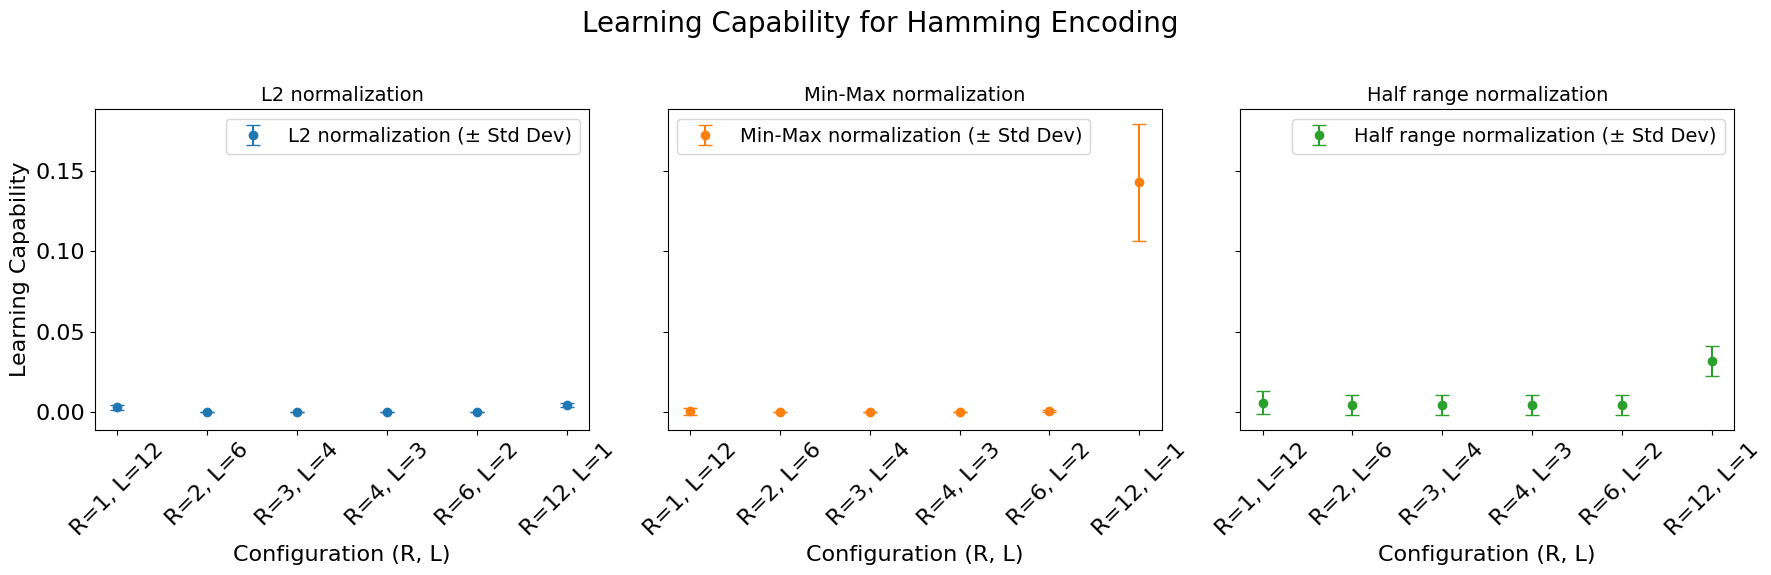

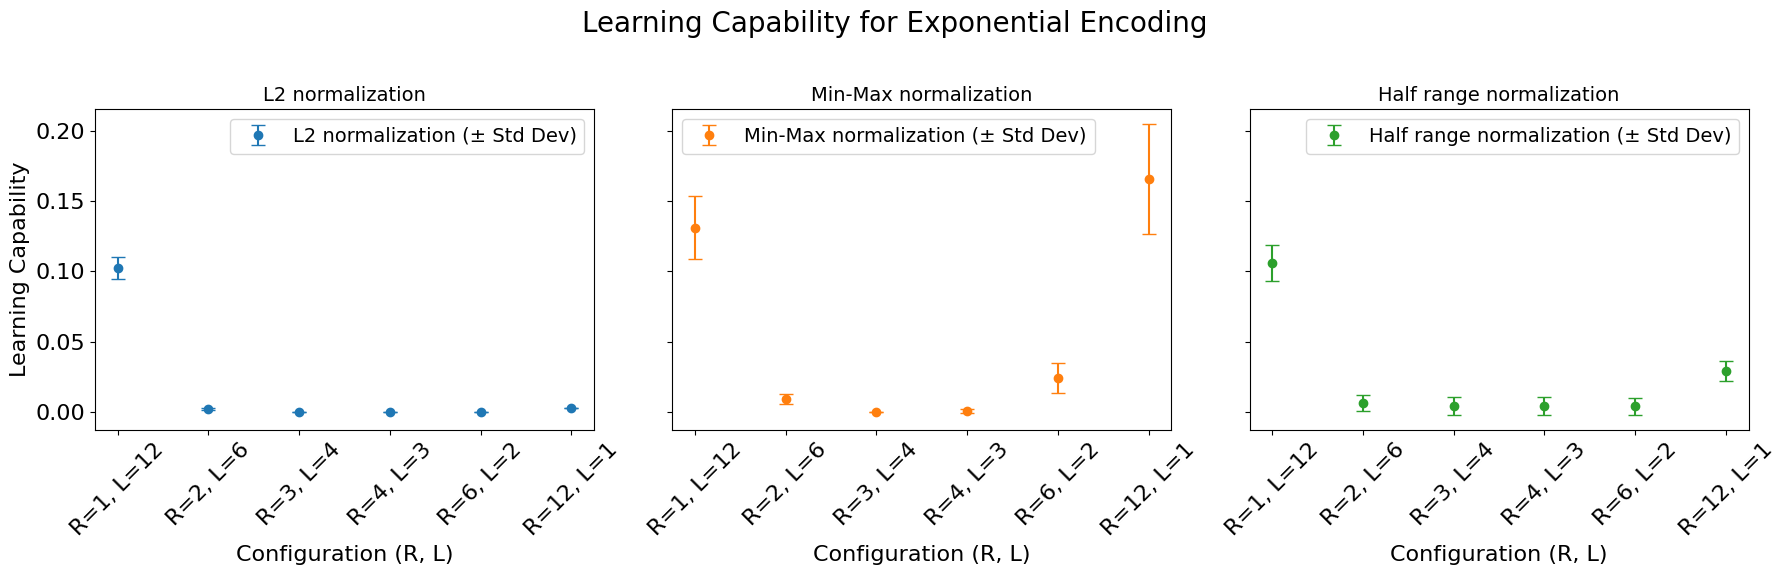

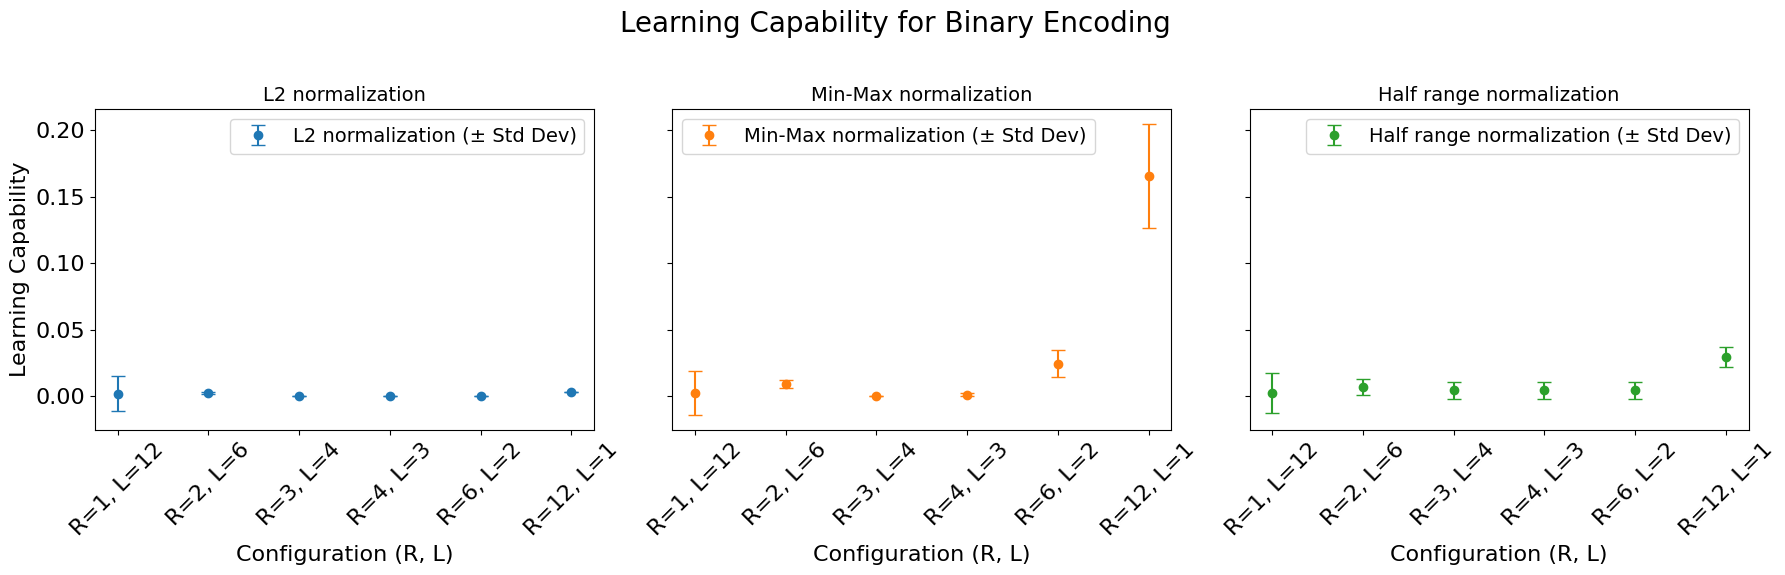

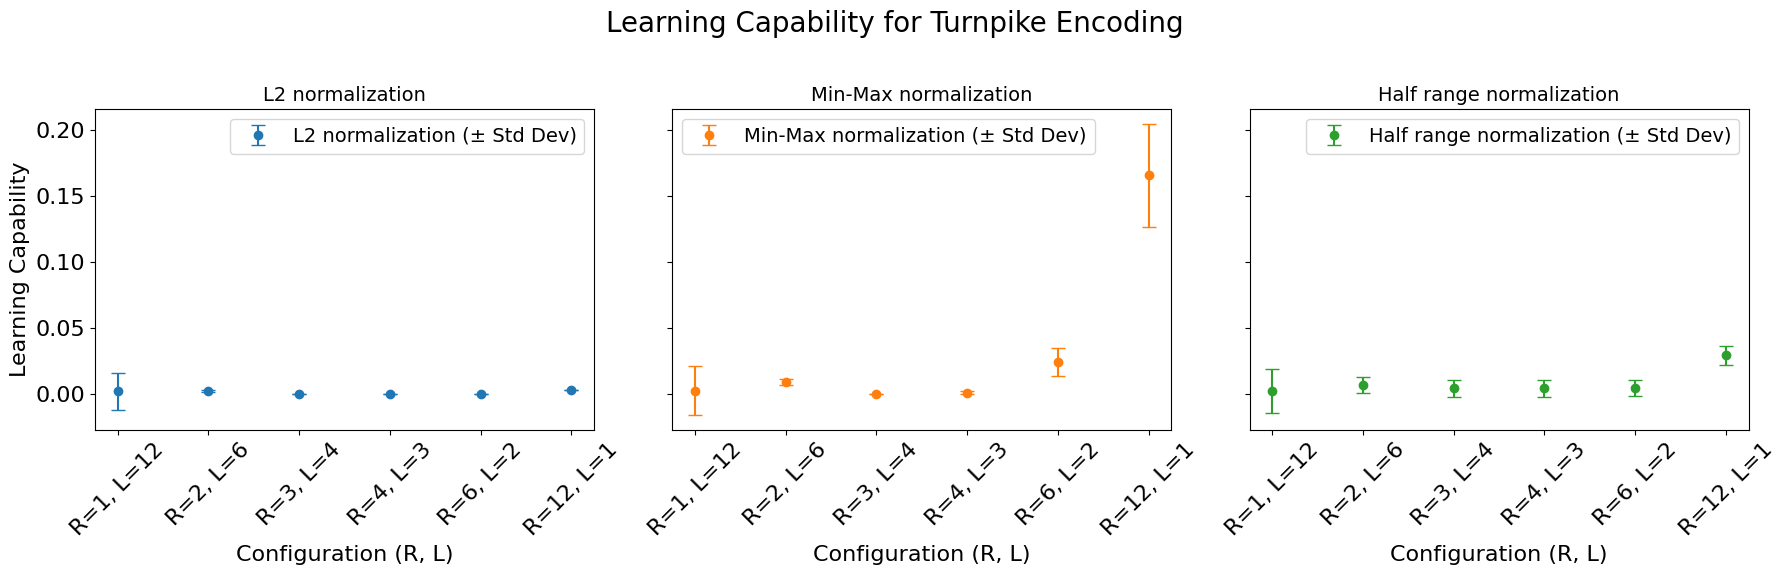

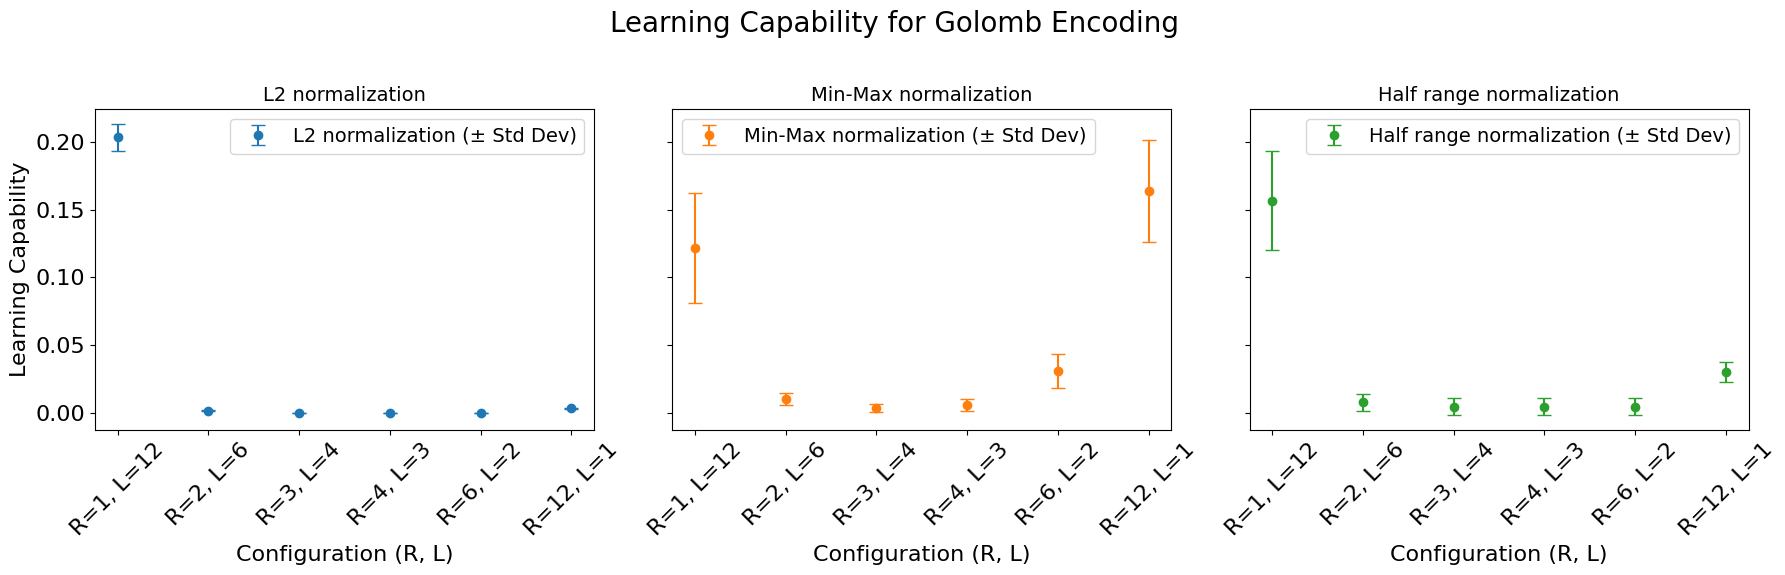

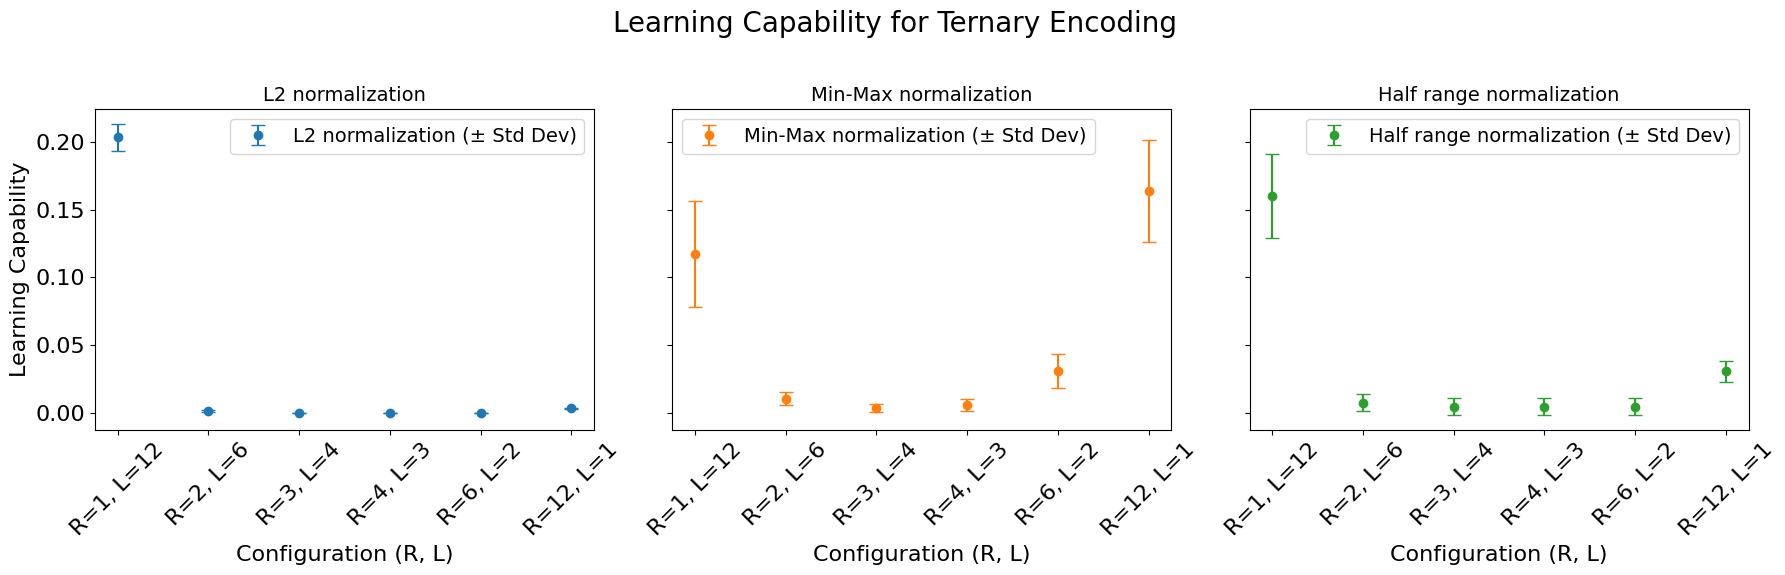

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the default Matplotlib style
plt.style.use('default')
# Load the data from the provided Excel file
file_path = 'Experiments_List.xlsx'
df = pd.read_excel(file_path)

# Define configurations
configurations = [
    (1, 12, "L2 normalization"),
    (1, 12, "Min-Max normalization"),
    (1, 12, "Half range normalization"),
    (2, 6, "L2 normalization"),
    (2, 6, "Min-Max normalization"),
    (2, 6, "Half range normalization"),
    (3, 4, "L2 normalization"),
    (3, 4, "Min-Max normalization"),
    (3, 4, "Half range normalization"),
    (4, 3, "L2 normalization"),
    (4, 3, "Min-Max normalization"),
    (4, 3, "Half range normalization"),
    (6, 2, "L2 normalization"),
    (6, 2, "Min-Max normalization"),
    (6, 2, "Half range normalization"),
    (12, 1, "L2 normalization"),
    (12, 1, "Min-Max normalization"),
    (12, 1, "Half range normalization")
]

# Define fixed colors for each normalization method
normalization_colors = {
    "L2 normalization": 'tab:blue',
    "Min-Max normalization": 'tab:orange',
    "Half range normalization": 'tab:green'
}

# Define the list of normalizations in the desired order
normalizations = ["L2 normalization", "Min-Max normalization", "Half range normalization"]

# Iterate over each unique encoding
for encoding in df['Encoding'].unique():
    # Create a figure with three horizontal subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    fig.suptitle(f"Learning Capability for {encoding} Encoding", fontsize=20)

    # Iterate over each normalization and corresponding subplot axis
    for ax, norm in zip(axes, normalizations):
        # Initialize lists for plotting
        x_labels = []
        y_values = []
        y_errors = []
        current_color = normalization_colors[norm]  # Get the fixed color for the current normalization

        # Iterate through configurations and filter by normalization
        for R, L, configuration_norm in configurations:
            if configuration_norm != norm:
                continue  # Skip configurations that don't match the current normalization

            # Filter the DataFrame for the current encoding, R, L, and normalization
            subset = df[
                (df['Encoding'] == encoding) &
                (df['R'] == R) &
                (df['L'] == L) &
                (df['Normalization'] == norm)
                ]

            if not subset.empty:
                label = f"R={R}, L={L}"
                x_labels.append(label)
                y_values.append(subset['Learning Capability (Exp)'].values[0])
                y_errors.append(subset['Standard Deviation (Exp)'].values[0])

        # Plot the error bars for the current normalization
        ax.errorbar(
            x_labels,
            y_values,
            yerr=y_errors,
            fmt='o',
            color=current_color,
            capsize=5,
            label=f"{norm} (± Std Dev)"
        )

        # Set subplot title and labels with increased font size
        ax.set_title(norm, fontsize=14)
        ax.set_xlabel("Configuration (R, L)", fontsize=16)
        ax.tick_params(axis='x', labelsize=16, rotation=45)
        ax.tick_params(axis='y', labelsize=16)
        # Uncomment the following line if you prefer a logarithmic y-scale:
        #ax.set_yscale('log')
        # Add legend for each subplot
        ax.legend(fontsize=14)

    # Set common y-label with increased font size
    axes[0].set_ylabel("Learning Capability", fontsize=16)

    # Adjust layout for better spacing
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save and show the figure
    filename = f"Learning_Capability_{encoding}.png"
    plt.savefig(filename)
    plt.show()